In [ ]:
# ! pip install -q -U langchain_openai langchain_core langgraph


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
from dotenv import load_dotenv

load_dotenv()

api_key= os.getenv("OPENAI_API_KEY")
if api_key is None:
    raise ValueError("OPENAI_API_KEY not set in .env")
else:
    print("API key laoded successfully.")

API key laoded successfully.


In [3]:
import base64
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

vision_llm = ChatOpenAI(model="gpt-4o")


def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
    """
    all_text = ""
    try:

        # Read image and encode as base64
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        # Prepare the prompt including the base64 image data
        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        # Call the vision-capable model
        response = vision_llm.invoke(message)
        all_text += response.content + "\n\n"

        return all_text.strip()
    except Exception as e:
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return " "


llm = ChatOpenAI(model="gpt-4o")


def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b


tools = [
    divide,
    extract_text
]
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [4]:
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The input document
    input_file: Optional[str]  # Contains file path, type (PNG)
    messages: Annotated[list[AnyMessage], add_messages]

In [5]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.utils.function_calling import convert_to_openai_tool


def assistant(state: AgentState):
    # System message
    textual_description_of_tool = """
    extract_text(img_path: str) -> str:
        Extract text from an image file using a multimodal model.

        Args:
            img_path: A local image file path (strings).

        Returns:
            A single string containing the concatenated text extracted from each image.
    divide(a: int, b: int) -> float:
        Divide a and b
"""
    image = state["input_file"]
    sys_msg = SystemMessage(content=f"You are an helpful agent that can analyse some images and run some computatio without provided tools :\n{textual_description_of_tool} \n You have access to some otpional images. Currently the loaded images is : {image}")

    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])], "input_file": state["input_file"]}

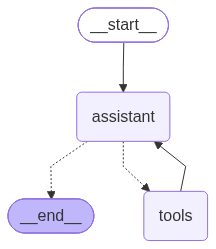

In [6]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [7]:
messages = [HumanMessage(content="Divide 6790 by 5")]

messages = react_graph.invoke({"messages": messages, "input_file": None})

OpenAIRateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

In [ ]:
for m in messages['messages']:
    m.pretty_print()